In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
from pandas.plotting import lag_plot, autocorrelation_plot
import plotly.graph_objects as go
import mplfinance as mpf
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/analyzing-and-prediction-of-bitcoin-pricing/BTC-USD.csv
/kaggle/input/btc-usd-till-2024/BTC-USD.csv


In [2]:
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.8 MB/s eta 0:00:00


In [4]:
df = pd.read_csv('/kaggle/input/analyzing-and-prediction-of-bitcoin-pricing/BTC-USD.csv')
df.shape

(2788, 7)

In [38]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2788.000000,2788.000000,2788.000000,2788.000000,2788.000000,2.788000e+03
mean,12114.051628,12432.075536,11764.920824,12126.416572,12126.416572,1.504640e+10
std,16612.538889,17044.777808,16119.346993,16615.381435,16615.381435,1.988339e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,612.573471,618.876495,609.665756,613.742477,613.742477,8.317548e+07
50%,6457.810059,6549.650147,6353.985107,6466.239990,6466.239990,5.401853e+09
75%,11024.040039,11388.611572,10722.320557,11056.325195,11056.325195,2.558002e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2788 entries, 0 to 2787
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2788 non-null   object 
 1   Open       2788 non-null   float64
 2   High       2788 non-null   float64
 3   Low        2788 non-null   float64
 4   Close      2788 non-null   float64
 5   Adj Close  2788 non-null   float64
 6   Volume     2788 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 152.6+ KB


In [27]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [28]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace = True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...
2022-05-01,37713.265625,38627.859375,37585.789063,38469.093750,38469.093750,27002760110
2022-05-02,38472.187500,39074.972656,38156.562500,38529.328125,38529.328125,32922642426
2022-05-03,38528.109375,38629.996094,37585.621094,37750.453125,37750.453125,27326943244


# ***Correlation heatmap***

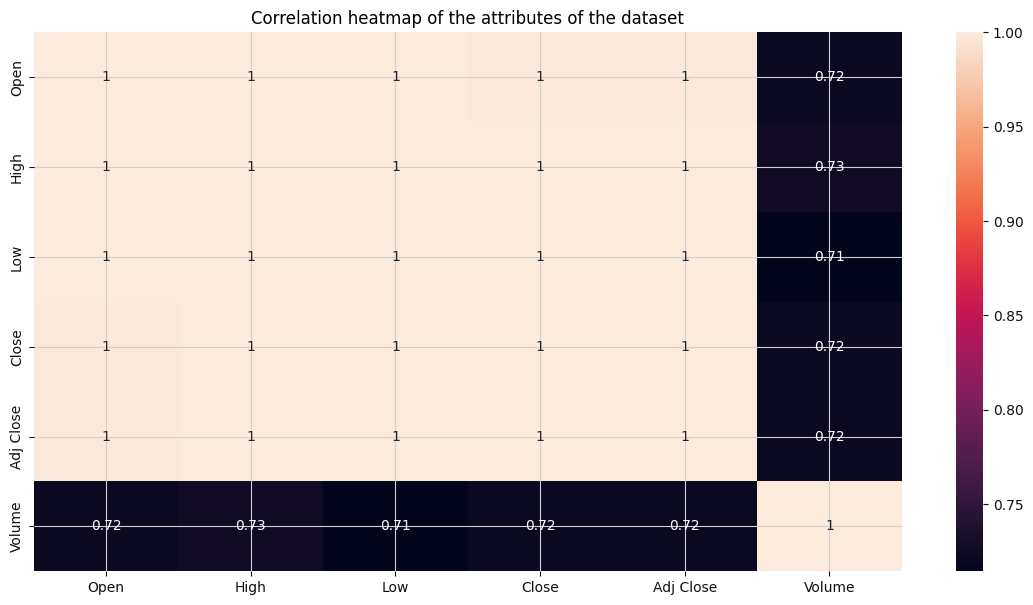

In [189]:
correlation_matrix = df.corr()

plt.figure(figsize=(14, 7))
sns.heatmap(data=correlation_matrix,annot = True) 

plt.title('Correlation heatmap of the attributes of the dataset')
plt.show()

<Axes: xlabel='Date'>

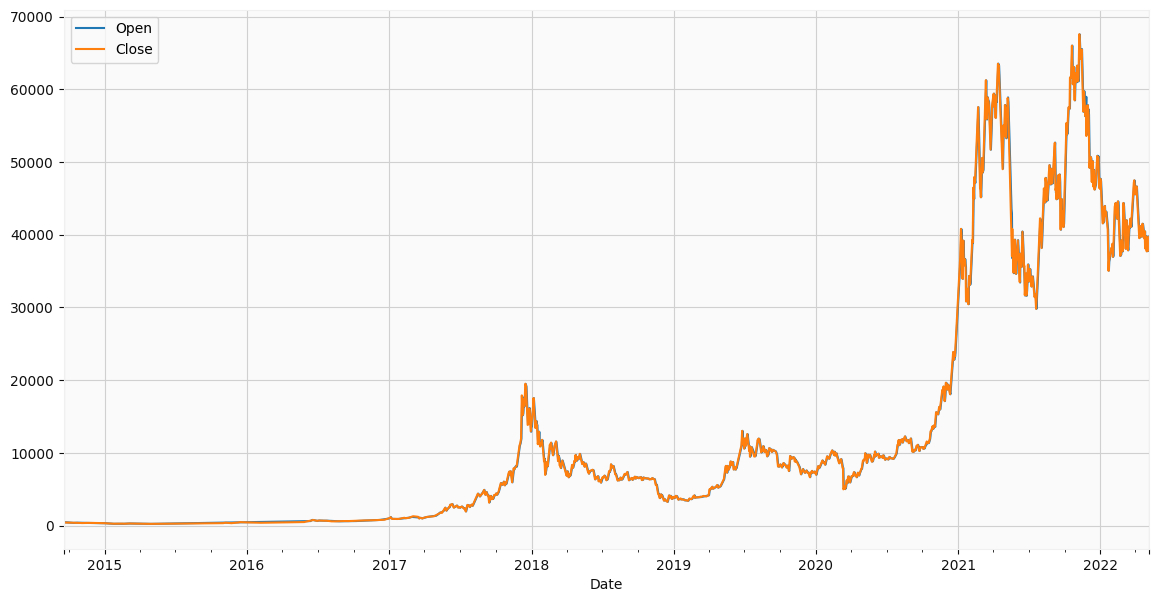

In [190]:
df[['Open','Close']].plot(figsize = (14,7),grid = 'True')

<Axes: xlabel='Date'>

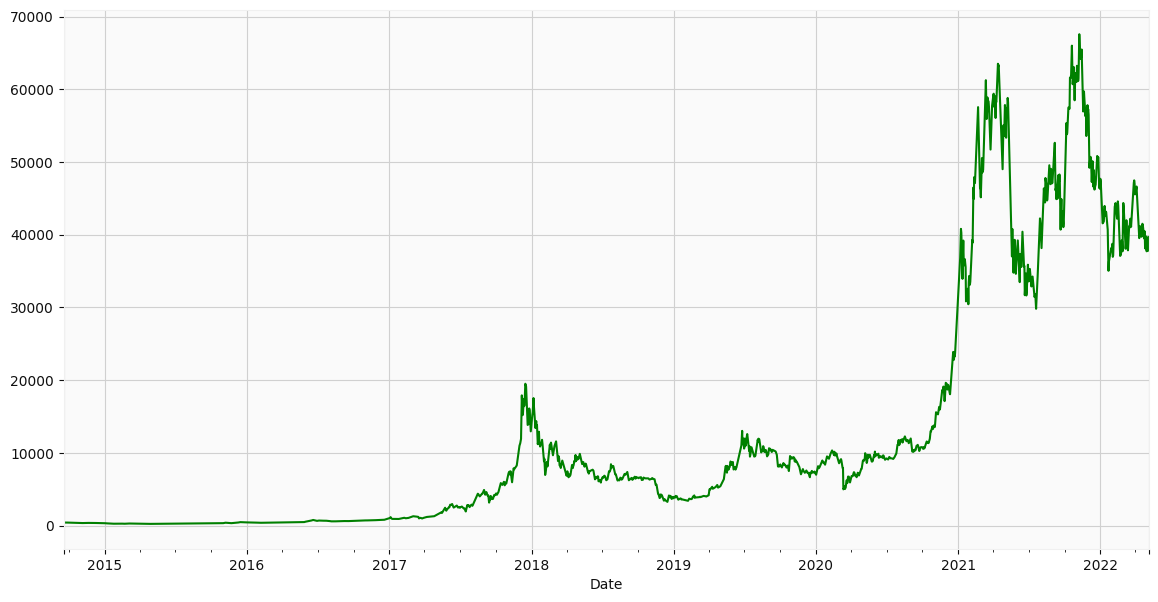

In [192]:
df['Adj Close'].plot(figsize = (14,7),color = 'green',grid = 'True')

# **Checking for Peak values and Trough values**

In [226]:
df = df.reset_index()

In [199]:
max_date = df.loc[df['Adj Close'].idxmax()]['Date']
max_date

Timestamp('2021-11-08 00:00:00')

In [200]:
max_value = df.loc[df['Adj Close'].idxmax()]['Adj Close']
max_value

67566.828125

In [201]:
min_date = df.loc[df['Adj Close'].idxmin()]['Date']
min_date

Timestamp('2015-01-14 00:00:00')

In [202]:
min_value = df.loc[df['Adj Close'].idxmin()]['Adj Close']
min_value

178.102997

# **Reasons for Bitcoin Reaching it's Highest value on November 8th of USD 67,567**

**ProShares Bitcoin Strategy ETF (BITO)**: Launched on October 19, 2021, BITO was the first Bitcoin futures ETF to be approved in the U.S., leading to increased market interest and liquidity.

**Taproot Upgrade:** Activated on November 14, 2021, Taproot was one of the most significant upgrades to the Bitcoin network in years. It enhanced privacy, efficiency, and the network's ability to support smart contracts.

**Public Interest and Media Coverage**: There was a significant amount of media coverage and public interest in Bitcoin and cryptocurrencies around this time, contributing to the hype and increased investment.

**Technological Advancements:** Positive developments in Bitcoin's underlying technology or improvements in scalability and security features may have increased its perceived value.

**Supply and Demand Dynamics:** Limited supply combined with increased demand from retail and institutional investors seeking exposure to cryptocurrencies could have driven prices upwards.**



After reaching its peak, Bitcoin experienced significant volatility, influenced by various factors including market corrections, changes in regulatory stance, macroeconomic shifts, and sentiment in the broader cryptocurrency market.
The ProShares Bitcoin Strategy ETF is an exchange-traded fund (ETF) that aims to track the performance of bitcoin futures contracts. This ETF allows investors to gain exposure to bitcoin without directly owning the cryptocurrency itself. Here are some key points about the ProShares Bitcoin Strategy ETF:

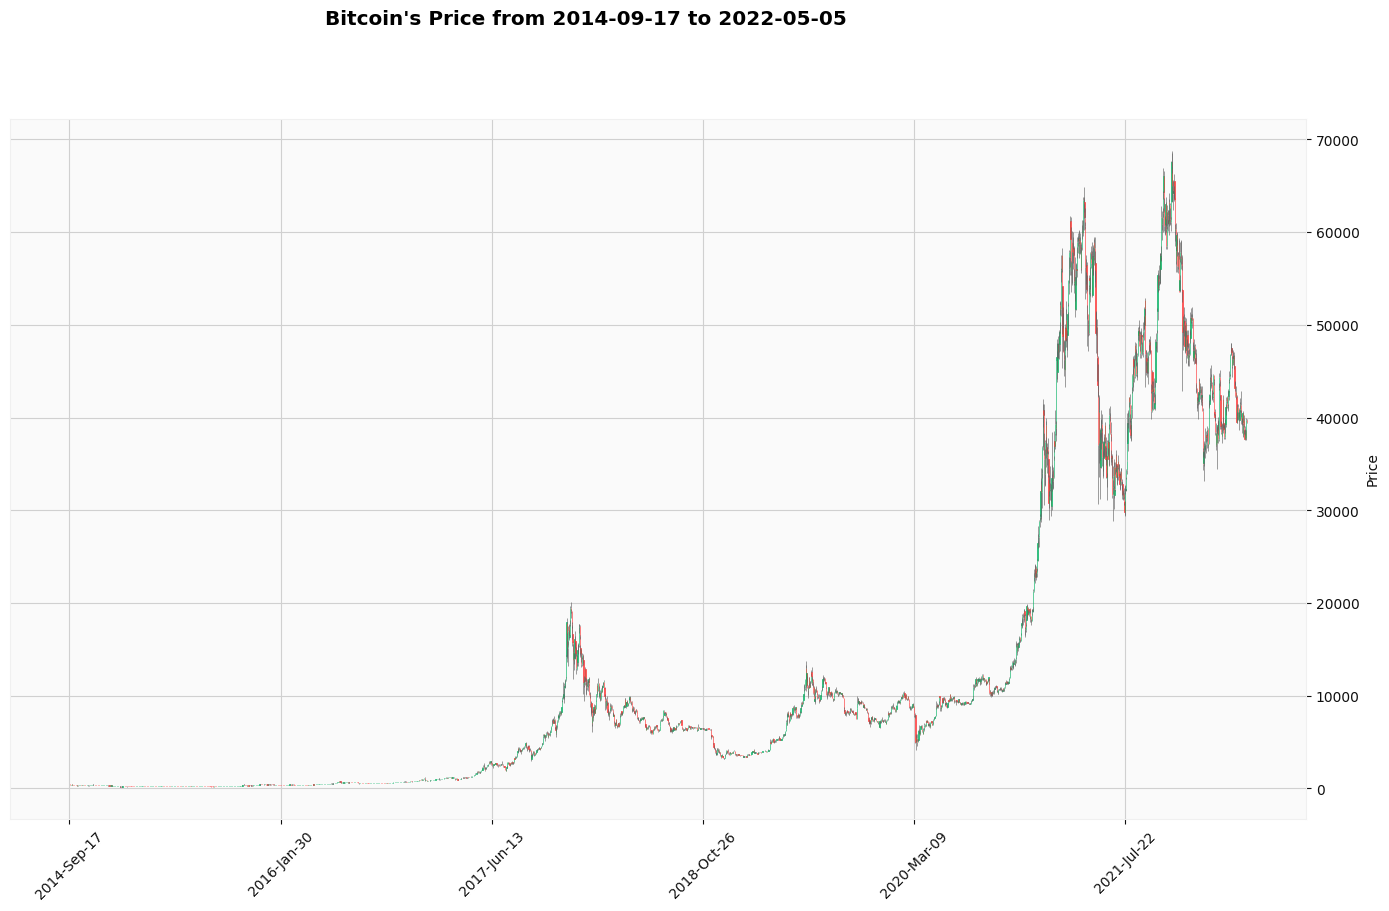

In [204]:
df['Date'] = pd.to_datetime(df['Date'])

start_date = '2014-09-17'
end_date = '2022-05-05'
mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)
df_filtered = df[mask]

df_filtered.set_index('Date', inplace=True)

mpf.plot(df_filtered, type='candle', style='yahoo', 
         title="Bitcoin's Price from 2014-09-17 to 2022-05-05",
         ylabel='Price', ylabel_lower='Volume', figratio=(16,8), figsize=(18,10))

plt.show()

In [170]:
df.isna().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

# Volume of units of Bitcoin traded during a span of 8 years 

<Axes: xlabel='Date'>

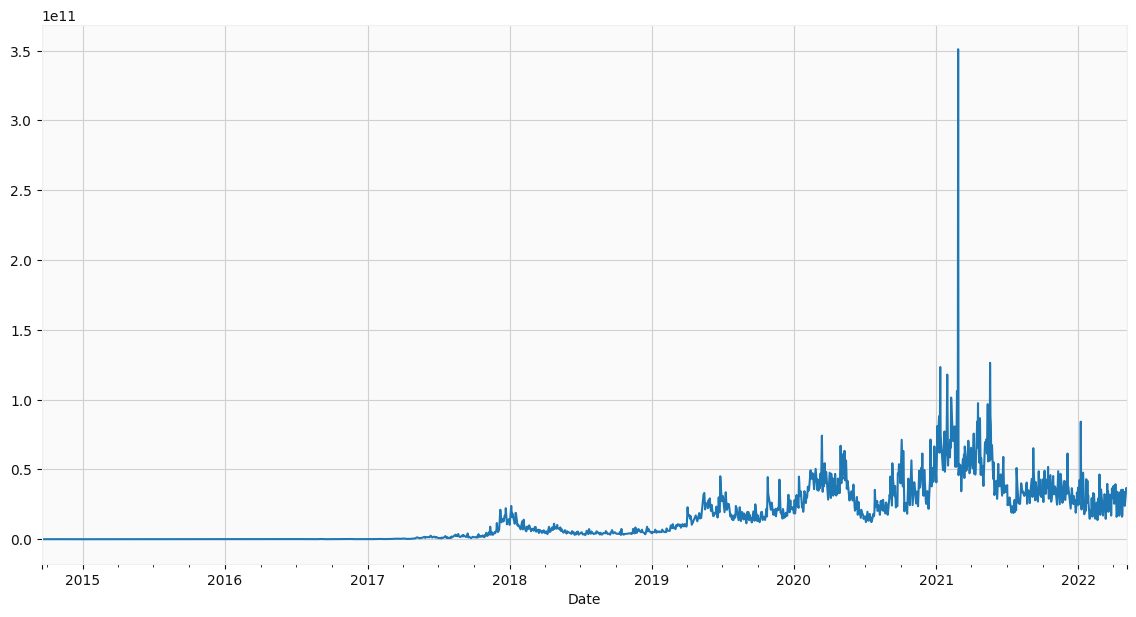

In [224]:
df['Volume'].plot(figsize = (14,7))

In [227]:
max_shares_date = df.loc[df['Volume'].idxmax()]['Date']
max_shares = df.loc[df['Volume'].idxmax()]
max_shares

Date         2021-02-26 00:00:00
Open                47180.464844
High                48370.785156
Low                  44454.84375
Close               46339.761719
Adj Close           46339.761719
Volume              350967941479
Name: 2354, dtype: object

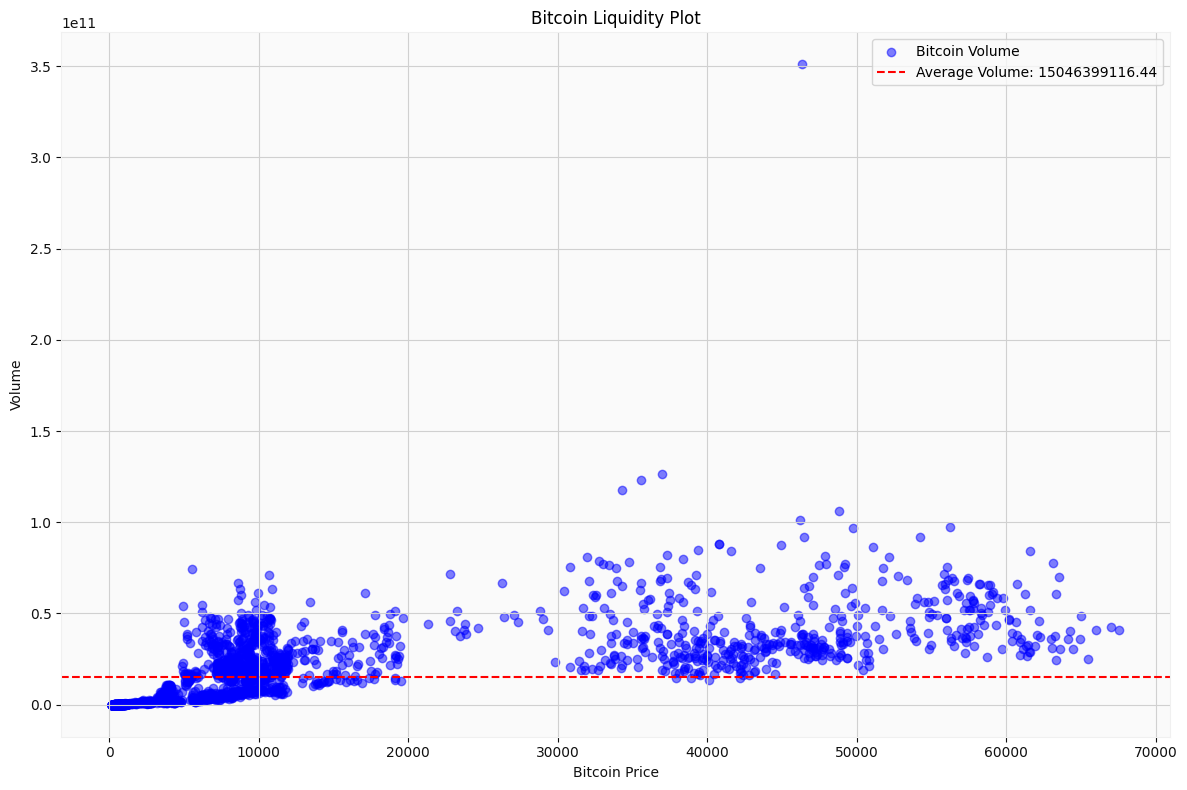

In [207]:
average_volume = df_filtered['Volume'].mean()
price_range = df_filtered['Close'].max() - df_filtered['Close'].min()

plt.figure(figsize=(12, 8))
plt.scatter(df_filtered['Adj Close'], df_filtered['Volume'], alpha=0.5, color='b', label='Bitcoin Volume')


plt.axhline(y=average_volume, color='r', linestyle='--', label=f'Average Volume: {average_volume:.2f}')

plt.xlabel('Bitcoin Price')
plt.ylabel('Volume')
plt.title('Bitcoin Liquidity Plot')
plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

#  **Insights Gained from the Liquidity Plot** 📈

**1) Significant Volume Cluster Around the USD 10,000 Price Level 💵:** There was a significant volume cluster around the USD 10,000 price level. This suggests that there was substantial trading activity and interest in Bitcoin when its price was around this level. High density indicates a strong concentration of buying and selling orders.

**2) Clusters Forming as Price Moved from USD 30,000 Upwards 📊:** Clusters started to form again as the price of Bitcoin moved from USD 30,000 upwards. This indicates renewed interest and possibly more focused trading activity at these higher price levels.

**3) Decreased Density of Clusters at USD 60,000+ 📉:** As Bitcoin's price climbed towards USD 60,000+, the density of clusters decreased again. This could suggest that while trading activity remained present, it was less concentrated compared to lower price ranges.


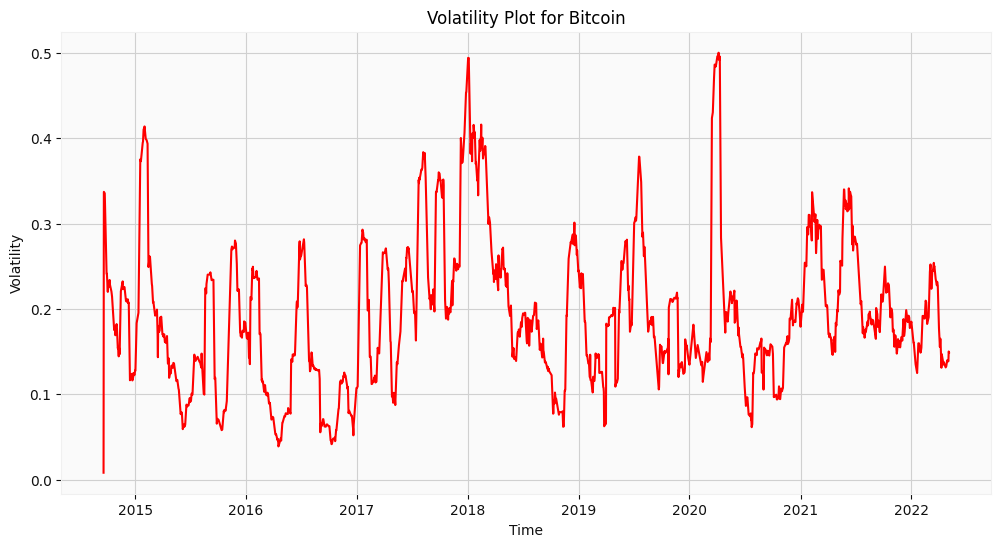

In [208]:

df['Daily_Return'] = df['Close'].pct_change()

window = 30 

df['Volatility'] = df['Daily_Return'].rolling(window, min_periods=1).std() * np.sqrt(window)


plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'], label='Volatility', color='red')
plt.title('Volatility Plot for Bitcoin')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.grid(True)
plt.show()


In [209]:
volatility_peaks = df.loc[df['Volatility'].idxmax()]['Date']
volatility_peaks

Timestamp('2020-04-06 00:00:00')

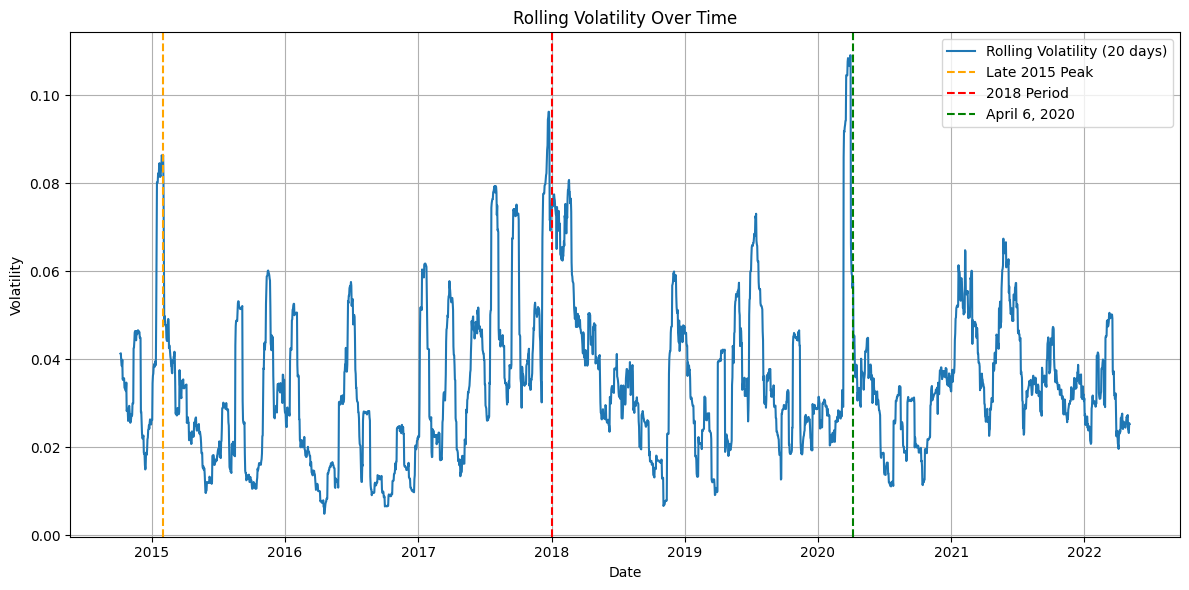

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df['Return'] = df['Close'].pct_change()
rolling_window = 20 
df['Volatility'] = df['Return'].rolling(window=rolling_window).std()

# Plot rolling volatility
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'], label='Rolling Volatility (20 days)')
plt.axvline(pd.to_datetime('2015-02-01'), color='orange', linestyle='--', label='Late 2015 Peak')
plt.axvline(pd.to_datetime('2018-01-01'), color='r', linestyle='--', label='2018 Period')
plt.axvline(pd.to_datetime('2020-04-06'), color='g', linestyle='--', label='April 6, 2020')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Rolling Volatility Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# **Factors contributing to High Volatility in the year 2018** 🚀

**1) Trade Wars 🌍:** The U.S.-China trade war escalated in 2018, causing significant uncertainty in global markets. Tariffs and trade barriers introduced by both countries affected many industries, leading to fluctuations in stock prices.

**2) Interest Rate Hikes 📈:** The U.S. Federal Reserve raised interest rates several times in 2018. Higher interest rates can lead to lower consumer spending and business investment, causing concerns about economic growth and leading to market volatility.

**3) Tech Sector Volatility 💻:** Major tech companies faced regulatory scrutiny and privacy concerns, impacting their stock prices. High-growth tech stocks are often more volatile, contributing to overall market volatility.

**4) Political Uncertainty ⚖️:** Mid-term elections in the U.S. and political developments in Europe (such as Brexit negotiations) created additional uncertainty.

# **Factors Contributing to High Volatility in Early 2020 (April 6, 2020):** 🌟

**1) COVID-19 Pandemic 🦠:** The onset of the COVID-19 pandemic in early 2020 led to unprecedented market volatility. The uncertainty surrounding the virus's spread, economic shutdowns, and health impacts caused dramatic market fluctuations.

**2) Oil Price Crash 🛢️:** In March 2020, a price war between Saudi Arabia and Russia led to a significant drop in oil prices, exacerbating market concerns and contributing to volatility.

**3) Global Economic Shutdown 🌏:** Lockdowns and restrictions implemented worldwide to curb the spread of COVID-19 severely impacted economic activity, leading to fears of a global recession.

**4) Government and Central Bank Actions 🏦:** Massive fiscal stimulus packages and monetary interventions by governments and central banks to support the economy created uncertainty about their long-term impacts.

# **Factors Contributing to High Volatility After 2015:** 🔍

**Global Economic Concerns 🌐:**

**China’s Economic Slowdown 📉:** In mid-2015, concerns about China's economic slowdown and the devaluation of the Chinese yuan led to significant market turbulence. China's stock market experienced dramatic drops, affecting global markets.

**Commodity Price Declines 📉:** The decline in commodity prices, especially oil, continued to create uncertainty and volatility in global markets. The oil price drop affected energy companies and economies dependent on commodity exports.

**First Rate Hike Since 2008 📈:** In December 2015, the U.S. Federal Reserve raised interest rates for the first time since the 2008 financial crisis. The anticipation and actual implementation of this rate hike caused market jitters as investors adjusted their expectations.

**Geopolitical Tensions 🌍:**

**Brexit Referendum Announcement 🇬🇧:** In 2015, the UK announced a referendum on its membership in the European Union, which was held in June 2016. The uncertainty surrounding Brexit had a significant impact on financial markets leading up to the referendum.

**Earnings and Economic Data 📊:**

**Mixed Corporate Earnings 📑:** Corporate earnings reports during this period were mixed, with some companies performing well while others struggled, leading to increased market volatility.

**Economic Data 📈:** Various economic indicators, including GDP growth rates, employment figures, and inflation data, contributed to market movements as investors reacted to new information.


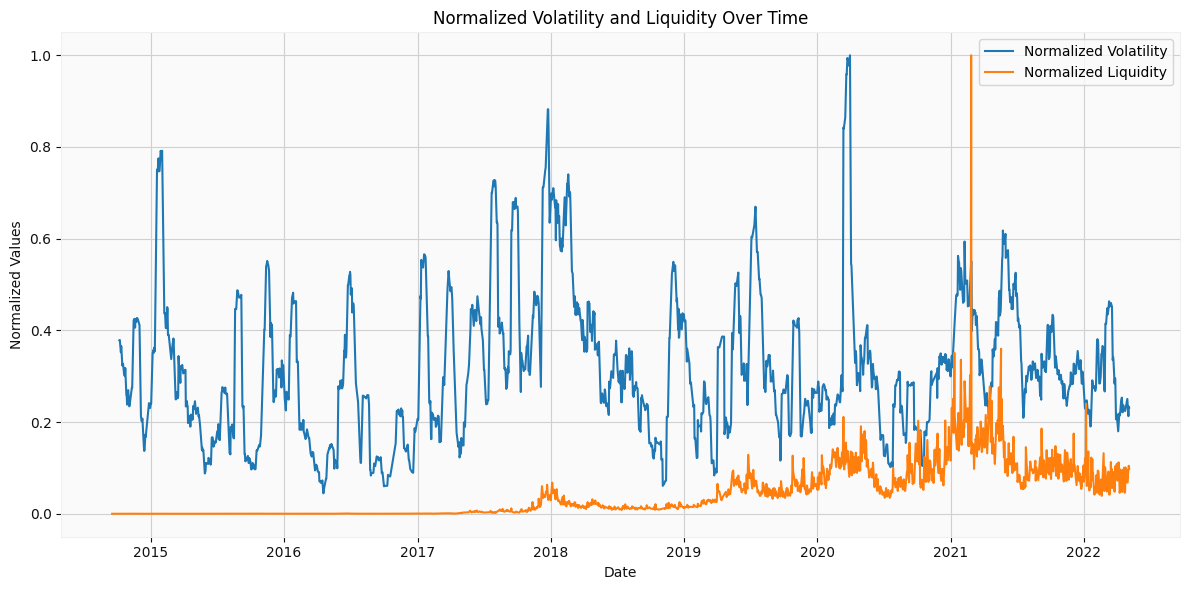

In [ ]:
df['Volatility'] = df['Volatility'] / df['Volatility'].max()
df['Volume'] = df['Volume'] / df['Volume'].max()

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Volatility'], label='Normalized Volatility')
plt.plot(df['Date'], df['Volume'], label='Normalized Liquidity')
plt.xlabel('Date')
plt.ylabel('Normalized Values')
plt.title('Normalized Volatility and Liquidity Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

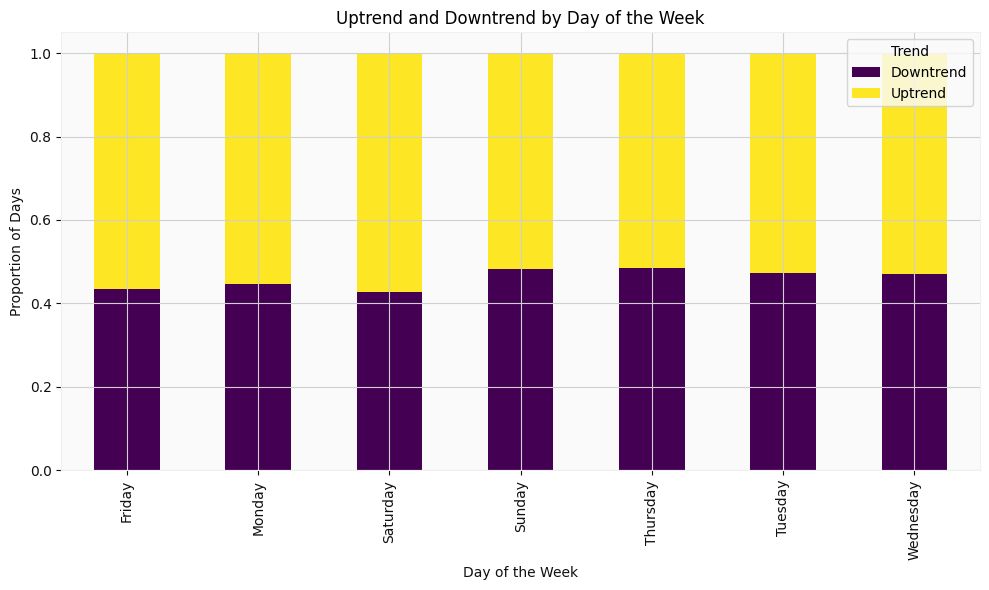

In [212]:
df['Date'] = pd.to_datetime(df['Date'])
df['Return'] = df['Close'].pct_change()
df['Trend'] = df['Return'].apply(lambda x: 'Uptrend' if x > 0 else 'Downtrend')
df['Day_of_Week'] = df['Date'].dt.day_name()

trend_by_day = df.groupby(['Day_of_Week', 'Trend']).size().unstack().fillna(0)
trend_by_day = trend_by_day.div(trend_by_day.sum(axis=1), axis=0)

trend_by_day.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Uptrend and Downtrend by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Proportion of Days')
plt.legend(title='Trend')
plt.grid(True)
plt.tight_layout()
plt.show()


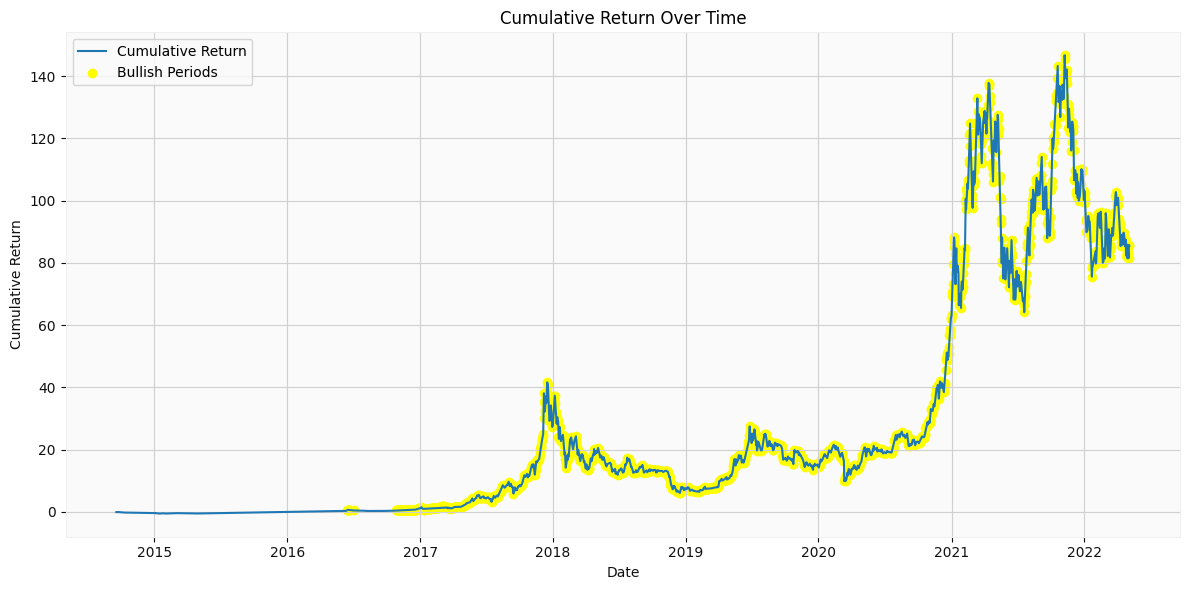

In [213]:
df['Cumulative_Return'] = (1 + df['Return']).cumprod() - 1
bullish_periods = df[df['Cumulative_Return'] > 0.5]  

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Cumulative_Return'], label='Cumulative Return')
plt.scatter(bullish_periods['Date'], bullish_periods['Cumulative_Return'], color='yellow', label='Bullish Periods')
plt.title('Cumulative Return Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 19.2 MB/s eta 0:00:0000:01


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2788 entries, 0 to 2787
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2788 non-null   object 
 1   Open       2788 non-null   float64
 2   High       2788 non-null   float64
 3   Low        2788 non-null   float64
 4   Close      2788 non-null   float64
 5   Adj Close  2788 non-null   float64
 6   Volume     2788 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 152.6+ KB
